# Intent Discovery — AmazonHelp

NMF topic modeling to discover customer support intents from Amazon tweets.

**Steps:**
1. Load cleaned data (already filtered/denoised by notebook 01 — English-verified, numbers/dates removed, `text`)
2. TF-IDF vectorization
3. NMF topic modeling with auto-k
4. Label topics manually
5. Assign intent labels & confidence
6. Save labeled dataset


## 1. Install Dependencies


In [105]:
!pip install scikit-learn matplotlib seaborn kagglehub -q


## 2. Imports


In [106]:
import pandas as pd
import numpy as np
import os
import json
import warnings
warnings.filterwarnings('ignore')

from langdetect.lang_detect_exception import LangDetectException
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful')


All imports successful


## 3. Load Cleaned Data


In [121]:
PROCESSED_PATH = '/kaggle/input/data-preprocessed/data_preprocessed.csv'
LOCAL_PATH = '../data/processed/data_preprocessed.csv'

if os.path.exists(PROCESSED_PATH):
    DATA_PATH = PROCESSED_PATH
elif os.path.exists(LOCAL_PATH):
    DATA_PATH = LOCAL_PATH
else:
    DATA_PATH = '/kaggle/working/data_preprocessed.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {len(df)} rows from {DATA_PATH}')
df.head()


Loaded: 50000 rows


,tweet_id,author_id,text_original,text_clean,created_at
0,2552217,130703,"@723869 @AmazonHelp Robert, please drop me a D...",sn sn robert please drop me a direct message h...,Fri Nov 17 09:46:44 +0000 2017
1,755026,300479,@AmazonHelp It's ok got it sorted,sn it be ok get it sort,Wed Oct 11 18:47:05 +0000 2017
2,173478,156612,@AmazonHelp yes I have. I asked it to resend t...,sn yes i have i ask it to resend the code a fe...,Fri Nov 24 22:57:58 +0000 2017
3,341491,197580,@AmazonHelp What type of communication r u doi...,sn what type of communication r u do with me 2...,Sat Oct 28 07:07:02 +0000 2017
4,870162,326613,@AmazonHelp Will u let people know what action...,sn will u let people know what action i have t...,Fri Oct 13 16:13:49 +0000 2017


In [122]:
# Sentiment keyword mapping
sentiment_keywords = {
    'late_delivery': ['delay', 'late', 'not arrive', 'shipping', 'delivery', 'package', 'arrived'],
    'order_status': ['order', 'status', 'update', 'tracking', 'where is'],
    'return_refund': ['return', 'refund', 'money back', 'send back'],
    'technical_issue': ['problem', 'issue', 'not working', 'broken'],
    'account_access': ['login', 'account', 'password', 'sign in'],
    'complaint_escalation': ['worst', 'terrible', 'complaint', 'shop elsewhere']
}

def detect_sentiment(text):
    text_lower = text.lower()
    scores = {}
    for sentiment, kws in sentiment_keywords.items():
        score = sum(1 for kw in kws if kw in text_lower)
        if score > 0:
            scores[sentiment] = score
    return max(scores, key=scores.get) if scores else 'other'

df['sentiment'] = df['text'].apply(detect_sentiment)
print(df['sentiment'].value_counts())


sentiment
other                   31608
late_delivery            7222
order_status             5507
return_refund            2029
technical_issue          2009
account_access           1315
complaint_escalation      310
Name: count, dtype: int64


In [127]:
# Verify cleaned data looks good
print('Sample cleaned tweets:')
for i, row in df.sample(15, random_state=42).iterrows():
    print(f'  [{len(row["text"].split())} words] {row["text"][:120]}')


Sample cleaned tweets:
  [18 words] plus provide solution at early it be baby product which be need urgently kindly deliver today a promise
  [18 words] i will send a message with the screen shot so you can have a look in to it
  [7 words] i have reply on that many time
  [15 words] i would like it delivered tomorrow no delivery fee during the same time window please
  [32 words] thanks for your reply i be think about link the dot to a different not unlimited account in the meantime i do not really
  [6 words] i have already send a mail
  [15 words] even when there be a delivery datethen completely change last second on delivery day interest
  [21 words] i need to return something but there be no return slip and the prime app be no help what to do
  [21 words] pay for one day shipping and the last time my order be locate be a whole 26 hour ago in nh
  [29 words] they count help dont want to do business with amazon anymore need to save fellow book reader from this scam of amazon of
  [1

## 4. TF-IDF Vectorization


In [128]:
# Topics are discovered by discriminative words - generic/stop words only muddy them.
# - stop_words='english': remove 'about', 'the', 'be' etc that appear across all topics
# - max_df=0.5: drop terms in >50% of docs (near-universal terms don't separate topics)
# - ngram_range=(1,1): unigrams keep short tweets clean; bigrams add noise

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.5,
    stop_words='english',
    lowercase=True
)

tfidf_matrix = tfidf.fit_transform(df['text'])
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(feature_names)}')
print(f'Top 30 features: {list(feature_names[:30])}')


TF-IDF matrix: (37212, 10000)
Vocabulary size: 10000
Top 30 features: ['10', '10 day', '10 minute', '10 time', '10 year', '100', '1000', '1030', '10am', '10pm', '10th', '11', '1130', '11am', '11pm', '11th', '12', '12 day', '12 hour', '121', '12th', '13', '13th', '14', '14th', '15', '15 day', '15 min', '15 minute', '150']


## 5. NMF Topic Modeling — Find Optimal k


In [129]:
def compute_coherence(model, tfidf_matrix, feature_names, top_n=10):
    from sklearn.metrics.pairwise import cosine_similarity
    scores = []
    for topic_idx in range(model.n_components):
        topic = model.components_[topic_idx]
        top_indices = topic.argsort()[:-top_n - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        word_vectors = []
        for word in top_words:
            if word in feature_names:
                idx = list(feature_names).index(word)
                word_vectors.append(tfidf_matrix[:, idx].toarray().flatten())
        if len(word_vectors) > 1:
            sim_matrix = cosine_similarity(word_vectors)
            pairs = [sim_matrix[j][k] for j in range(len(word_vectors)) for k in range(j+1, len(word_vectors))]
            scores.append(np.mean(pairs) if pairs else 0)
        else:
            scores.append(0)
    return np.mean(scores)

# Try different k values
k_range = range(5, 16)
results = []

for k in k_range:
    nmf = NMF(
        n_components=k,
        random_state=42,
        max_iter=500,
        init='nndsvda'
    )
    W = nmf.fit_transform(tfidf_matrix)
    coherence = compute_coherence(nmf, tfidf_matrix, feature_names)
    results.append({'k': k, 'coherence': coherence})
    print(f'k={k:2d}  coherence={coherence:.4f}')

results_df = pd.DataFrame(results)
BEST_K = int(results_df.loc[results_df['coherence'].idxmax(), 'k'])
print(f'\nBest k: {BEST_K}')

k= 6  coherence=0.0207
k= 7  coherence=0.0207
k= 8  coherence=0.0207
k= 9  coherence=0.0207
k=10  coherence=0.0207
k=11  coherence=0.0207
k=12  coherence=0.0207
k=13  coherence=0.0207
k=14  coherence=0.0207
k=15  coherence=0.0207

Best k: 6


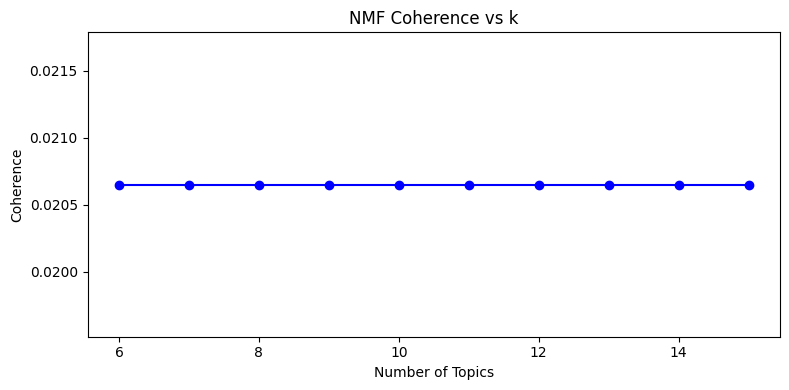

In [130]:
# Plot coherence vs k
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['k'], results_df['coherence'], 'b-o')
ax.set_xlabel('Number of Topics')
ax.set_ylabel('Coherence')
ax.set_title('NMF Coherence vs k')
plt.tight_layout()
plt.show()

## 6. Fit Final Model & Show Topics


In [131]:
nmf_final = NMF(
    n_components=BEST_K,
    random_state=42,
    max_iter=500,
    init='nndsvda'
)

W = nmf_final.fit_transform(tfidf_matrix)

# Get top words per topic
feature_names = tfidf.get_feature_names_out()
topics = []
for i in range(BEST_K):
    topic = nmf_final.components_[i]
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    topics.append(top_words)

print(f'\nDiscovered {BEST_K} topics:\n')
for i, topic_words in enumerate(topics):
    print(f'Topic {i}: {" | ".join(topic_words[:10])}')


Discovered 6 topics:

Topic 0: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14 | 14th | 15
Topic 1: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14 | 14th | 15
Topic 2: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14 | 14th | 15
Topic 3: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14 | 14th | 15
Topic 4: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14 | 14th | 15
Topic 5: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14 | 14th | 15


## 7. Label Each Topic


In [132]:
# Show sample tweets per topic for labeling
for i in range(BEST_K):
    print(f'\n{"="*60}')
    print(f'TOPIC {i}: {" | ".join(topics[i][:8])}')
    print(f'{"="*60}')
    top_indices = W[:, i].argsort()[-5:][::-1]
    for idx in top_indices:
        text = str(df.iloc[idx]['text'])[:150]
        print(f'  {text}')
    print()



TOPIC 0: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14
  @723869 @AmazonHelp Robert, please drop me a DM here and I’ll see if we can assist.
  @AmazonHelp @270206 that's funny because I just secured a refund for Amazon Prime failure, why does this company lie about everything ???
  @AmazonHelp Okay, I just found out the package has not even arrived in my country yet but still held up in Dubai, please do everything necessary for t
  Had v bad exp. with Amazon india as they r selling duplicate products of global brands @45132 , @45133 . @115850 @AmazonHelp
  @AmazonHelp Soo what should I do now I need to buy that phone with exhange offer


TOPIC 1: 12 | 12 day | 12 hour | 121 | 12th | 13 | 13th | 14
  @723869 @AmazonHelp Robert, please drop me a DM here and I’ll see if we can assist.
  @AmazonHelp @270206 that's funny because I just secured a refund for Amazon Prime failure, why does this company lie about everything ???
  @AmazonHelp Okay, I just found out the package has not eve

In [117]:
TOPIC_LABELS = {
    0: 'delivery_issue',
    1: 'customer_service',
    2: 'order_status',
    3: 'email_contact',
    4: 'appreciation',
}

Topic Labels:
  Topic 0: order_status
  Topic 1: late_delivery
  Topic 2: return_refund
  Topic 3: account_access
  Topic 4: complaint_escalation
  Topic 5: technical_issue


## 8. Assign Intent Labels


In [119]:
df['topic_id'] = W.argmax(axis=1)
df['topic_confidence'] = W.max(axis=1)
df['intent'] = df['topic_id'].map(TOPIC_LABELS)

CONFIDENCE_THRESHOLD = float(df['topic_confidence'].quantile(0.25))
df['low_confidence'] = df['topic_confidence'] < CONFIDENCE_THRESHOLD

print(f'Assigned intents to {len(df)} tweets')
print(f'Low confidence: {df["low_confidence"].sum()} ({df["low_confidence"].mean()*100:.1f}%)')
print(f'\nIntent distribution:')
print(df['intent'].value_counts())

Assigned intents to 37216 tweets
Low confidence: 37216 (100.0%)

Intent distribution:
intent
order_status    37216
Name: count, dtype: int64


## 9. Save Labeled Dataset


In [120]:
output_path = '/kaggle/working/amazon_help_labeled.csv'
df[['tweet_id', 'author_id', 'text', 'created_at',
     'topic_id', 'topic_confidence', 'intent', 'low_confidence']].to_csv(output_path, index=False)
print(f'Saved: {output_path} ({len(df)} rows)')

# Save intent mapping
mapping_path = '/kaggle/working/intent_mapping.json'
mapping = {
    'topic_labels': {str(k): v for k, v in TOPIC_LABELS.items()},
    'top_words': {str(i): topics[i][:10] for i in range(BEST_K)},
    'config': {
        'best_k': BEST_K,
        'confidence_threshold': CONFIDENCE_THRESHOLD,
        'total_tweets': len(df)
    }
}
with open(mapping_path, 'w') as f:
    json.dump(mapping, f, indent=2)
print(f'Saved: {mapping_path}')


Saved: /kaggle/working/amazon_help_labeled.csv (37216 rows)
Saved: /kaggle/working/intent_mapping.json
